In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge #
import warnings
from sklearn.pipeline import Pipeline

In [23]:
#Load data (California housingni yuklash)
housing = fetch_california_housing(as_frame=True)
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target
print('shape',df.shape)
print(f"\nFeatures: {housing.feature_names}")

shape (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [24]:
df.head(10)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [25]:
print(df['Price'].describe())

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: Price, dtype: float64


In [26]:
X = housing.data
y = housing.target
features_names = housing.feature_names

In [27]:
X = df.drop("Price", axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training: {len(X_train)}")
print(f"Testing: {len(X_test)}")

Training: 16512
Testing: 4128


In [28]:
baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)
print("Baseline (Liner Regression):")
print(f"R2 : {r2_score(y_test, y_pred_base):.4f}")
print(f"MAE : {mean_absolute_error(y_test, y_pred_base)*100000:,.0f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_base)):.4f}")


Baseline (Liner Regression):
R2 : 0.5758
MAE : 53,320
RMSE : 0.7456


In [29]:
model = RandomForestRegressor(n_estimators=50,random_state=42)
model.fit(X_train, y_train)
single_score = model.score(X_test, y_test)
print(f"single siplit r2: {single_score:.4f}")


single siplit r2: 0.8043


In [30]:
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
print('5-fold cross validation:')
print(f"Scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f}")
print(f"Scores: {cv_scores.std():.4f}")

5-fold cross validation:
Scores: [0.8062 0.7919 0.8068 0.8026 0.8035]
Mean: 0.8022
Scores: 0.0054


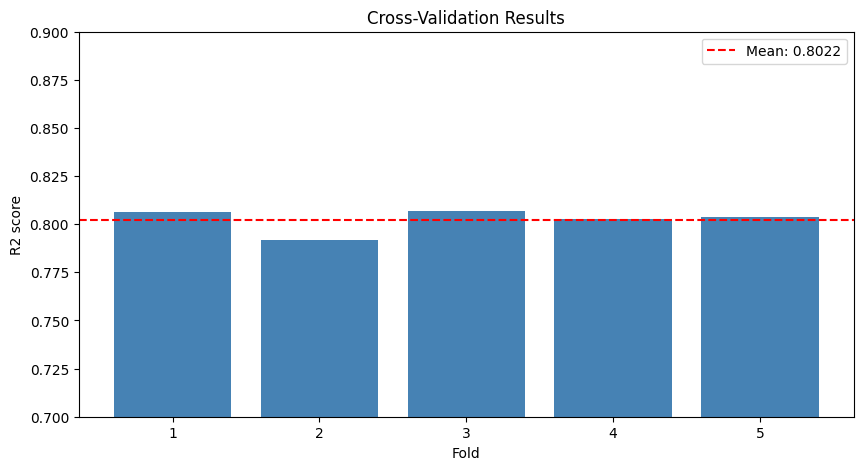

In [31]:
plt.figure(figsize=(10,5))
plt.bar(range(1,6), cv_scores, color='steelblue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R2 score')
plt.title('Cross-Validation Results')
plt.legend()
plt.ylim(0.7,0.9)#
plt.show()

In [32]:
n_trees_list = [10,50,100,200]
results = []
print("testing different n_estimators:")
for n_trees in n_trees_list:
    model = RandomForestRegressor(n_estimators=n_trees, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring="r2")
    results.append(cv_scores.mean())
    print(f"n_estimators: {n_trees},  R2: {cv_scores.mean():.4f}")

testing different n_estimators:
n_estimators: 10,  R2: 0.7775
n_estimators: 50,  R2: 0.7976
n_estimators: 100,  R2: 0.8003
n_estimators: 200,  R2: 0.8012


In [33]:
param_grid = {
    'n_estimators':[50,100],
    'max_depth':[None,10,20],
    'min_samples_split':[2,5]
}
n_combinations = 2*3*2
print(f"testing: {n_combinations} combinations:")


testing: 12 combinations:


In [34]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    # n_jobs=-1
)

print('running grid search...')
grid_search.fit(X_train, y_train)
print('tugadi')

running grid search...
tugadi


In [35]:
print('Best parameters')
print(grid_search.best_params_)
print(f"\nBest  cross-validation R2: {grid_search.best_score_:.4f}")


Best parameters
{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

Best  cross-validation R2: 0.8004


In [36]:
best_model = grid_search.best_estimator_
final_pred = best_model.predict(X_test)
print("\n Final results  on test:")
print(f"R2 : {r2_score(y_test, final_pred):.4f}")
print(f"MAE : ${mean_absolute_error(y_test, final_pred)*100000:,.0f}")



 Final results  on test:
R2 : 0.8044
MAE : $32,806


In [37]:
#compare before and after

In [38]:
# vizualization prediction
# baseline

#tuned modelni yonma yon chiqarish

In [ ]:
before_r2   = r2_score(y_test, y_pred_base)
before_mae  = mean_absolute_error(y_test, y_pred_base) * 100000
before_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))


after_r2   = r2_score(y_test, final_pred)
after_mae  = mean_absolute_error(y_test, final_pred) * 100000
after_rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("=== COMPARE: BEFORE vs AFTER ===")
print(f"BEFORE (Baseline - LinearRegression):  R2={before_r2:.4f} | MAE={before_mae:,.0f} | RMSE={before_rmse:.4f}")
print(f"AFTER  (Tuned - Best RandomForest):    R2={after_r2:.4f} | MAE={after_mae:,.0f} | RMSE={after_rmse:.4f}")


print("\nYAXSHIROQ MODEL mezoni: R2 katta bo'lsin, MAE va RMSE kichik bo'lsin.")

=== COMPARE: BEFORE vs AFTER ===
BEFORE (Baseline - LinearRegression):  R2=0.5758 | MAE=53,320 | RMSE=0.7456
AFTER  (Tuned - Best RandomForest):    R2=0.8044 | MAE=32,806 | RMSE=0.5062

YAXSHIROQ MODEL mezoni: R2 katta bo'lsin, MAE va RMSE kichik bo'lsin.


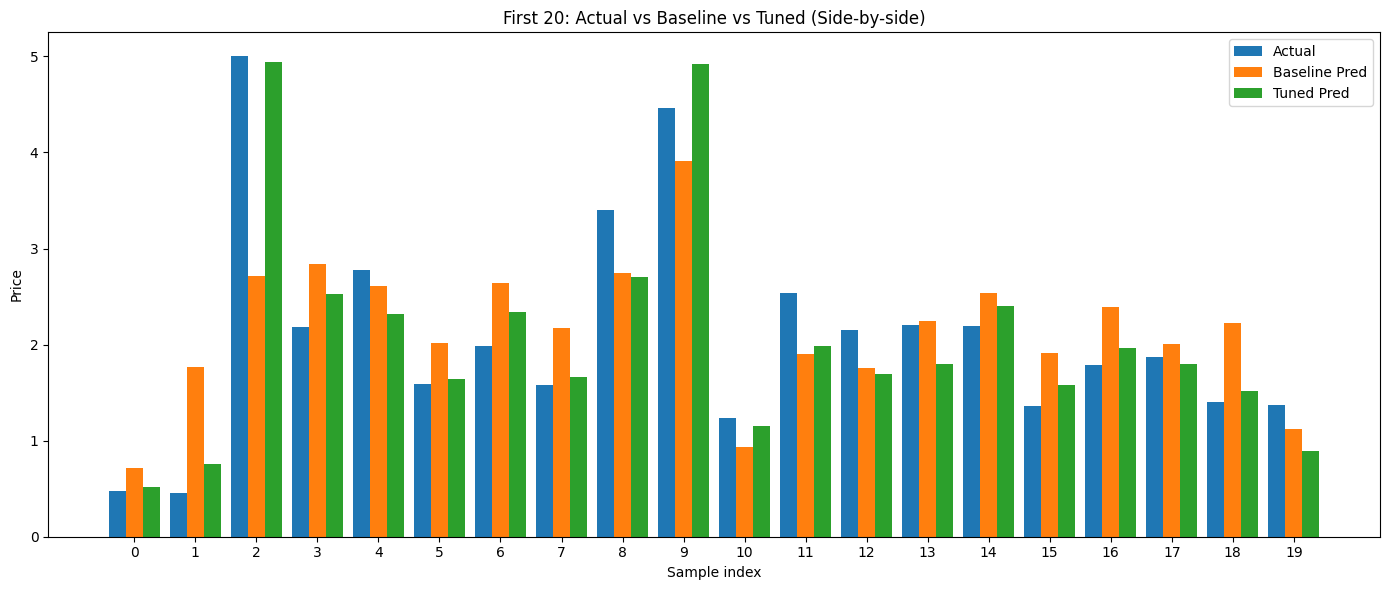

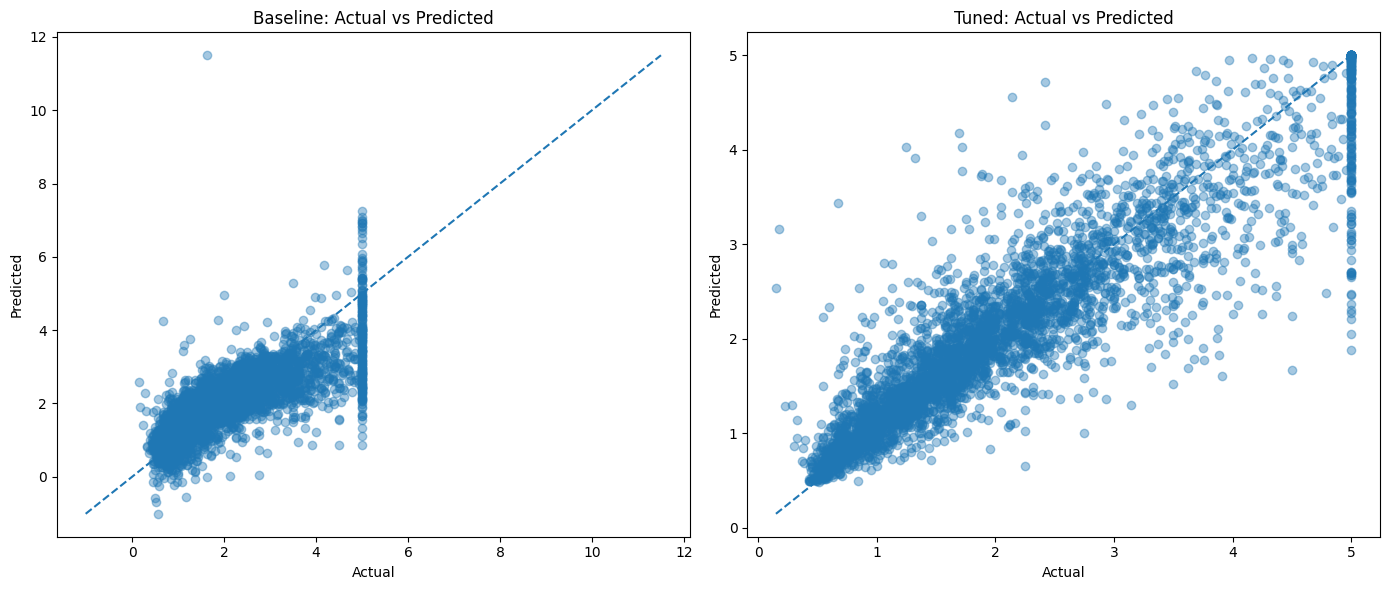

In [ ]:
# vizualization prediction

N = 20
actual = y_test.values[:N]
pred_base = y_pred_base[:N]
pred_tuned = final_pred[:N]

# 1) BAR CHART: Actual vs Baseline vs Tuned (yonma-yon)
x = np.arange(N)
w = 0.28

plt.figure(figsize=(14, 6))
plt.bar(x - w, actual, width=w, label="Actual")
plt.bar(x, pred_base, width=w, label="Baseline Pred")
plt.bar(x + w, pred_tuned, width=w, label="Tuned Pred")

plt.title(f"First {N}: Actual vs Baseline vs Tuned (Side-by-side)")
plt.xlabel("Sample index")
plt.ylabel("Price")
plt.xticks(x)
plt.legend()
plt.tight_layout()
plt.show()


# 2) SCATTER: Actual vs Predicted (Baseline va Tuned yonma-yon)
plt.figure(figsize=(14, 6))

# Baseline scatter
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_base, alpha=0.4)
mn = min(y_test.min(), y_pred_base.min())
mx = max(y_test.max(), y_pred_base.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Baseline: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Tuned scatter
plt.subplot(1, 2, 2)
plt.scatter(y_test, final_pred, alpha=0.4)
mn = min(y_test.min(), final_pred.min())
mx = max(y_test.max(), final_pred.max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.title("Tuned: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()